# Dataset Exploration

## 1. Counting the total no of images and labels

In [3]:
import os

DATASET_DIR = '../dataset'
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')
LABELS_DIR = os.path.join(DATASET_DIR, 'labels')

for folder in os.listdir(IMAGES_DIR):
    folder_path = os.path.join(IMAGES_DIR, folder)
    print(f"Count of {folder} images: {len(os.listdir(folder_path))}")

print()
for folder in os.listdir(LABELS_DIR):
    folder_path = os.path.join(LABELS_DIR, folder)
    print(f"Count of {folder} labels: {len(os.listdir(folder_path))}")

Count of test images: 40
Count of train images: 360

Count of train labels: 360


## 2. Checking if every image has its corresponding annotation

In [4]:
train_images = os.listdir(os.path.join(IMAGES_DIR, 'train'))
train_labels = os.listdir(os.path.join(LABELS_DIR, 'train'))

train_image_names = {os.path.splitext(file)[0] for file in train_images}
train_label_names = {os.path.splitext(file)[0] for file in train_labels}

images_without_labels = train_image_names - train_label_names
labels_without_images = train_label_names - train_image_names

print(f"Images without labels: {len(images_without_labels)}")
print(f"Labels without images: {len(labels_without_images)}")

Images without labels: 0
Labels without images: 0


## 3. Counting the total no of solar panels

In [8]:
total_panels = 0
panels_per_image = {}

for label_file in train_labels:
    file_path = os.path.join(os.path.join(LABELS_DIR, 'train'), label_file)

    with open(file_path, "r") as f:
        lines = f.readlines()

    total_panels += len(lines)
    panels_per_image[label_file] = len(lines)

print(f"Total no of solar panels: {total_panels}")

Total no of solar panels: 1051


## 4. Statistics

In [10]:
panel_counts = list(panels_per_image.values())

print(f"Total images: {len(panel_counts)}")
print(f"Total panels: {sum(panel_counts)}")
print(f"Minimum no of panels in an image: {min(panel_counts)}")
print(f"Maximum no of panels in an image: {max(panel_counts)}")
print(f"Average no of panels in an image: {sum(panel_counts) / len(panel_counts):.2f}")

Total images: 360
Total panels: 1051
Minimum no of panels in an image: 0
Maximum no of panels in an image: 20
Average no of panels in an image: 2.92


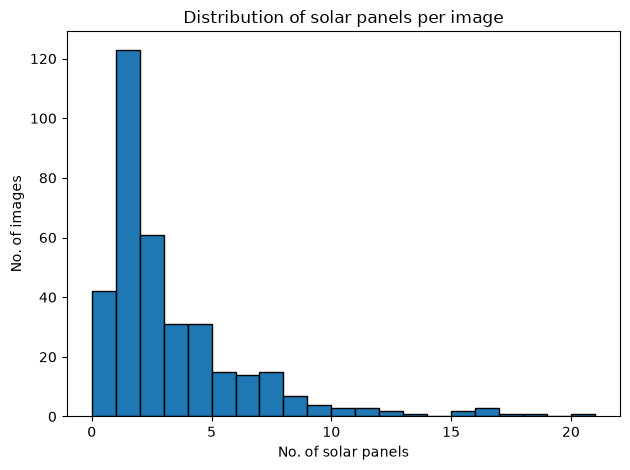

In [12]:
import matplotlib.pyplot as plt

plt.hist(
    panel_counts,
    bins=range(min(panel_counts), max(panel_counts) + 2),
    edgecolor="black"
)

plt.xlabel("No. of solar panels")
plt.ylabel("No. of images")
plt.title("Distribution of solar panels per image")

plt.tight_layout()
plt.show()

## 5. Extracting the annotation values

In [19]:
box_widths = []
box_heights = []
box_x_centers = []
box_y_centers = []

for label_file in train_labels:
    file_path = os.path.join(os.path.join(LABELS_DIR, 'train'), label_file)
    
    with open(file_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        values = line.strip().split()

        box_x_centers.append(float(values[1]))
        box_y_centers.append(float(values[2]))
        box_widths.append(float(values[3]))
        box_heights.append(float(values[4]))

## 6. Statistics

In [21]:
print(f"Width Statistics :- ")
print(f"Maximum width of bounding box: {max(box_widths)}")
print(f"Minimum width of bounding box: {min(box_widths)}")
print(f"Average width of bounding box: {sum(box_widths) / len(box_widths)}")

print(f"\nHeight Statistics :- ")
print(f"Maximum height of bounding box: {max(box_heights)}")
print(f"Minimum height of bounding box: {min(box_heights)}")
print(f"Average height of bounding box: {sum(box_heights) / len(box_heights)}")

Width Statistics :- 
Maximum width of bounding box: 0.99581589958159
Minimum width of bounding box: 0.01875
Average width of bounding box: 0.2633993076196907

Height Statistics :- 
Maximum height of bounding box: 0.8899224806201551
Minimum height of bounding box: 0.011598649983130649
Average height of bounding box: 0.19598822298386095


In [23]:
box_areas = []

for width, height in zip(box_widths, box_heights):
    area = width * height
    box_areas.append(area)

print(f"Average box area: {sum(box_areas) / len(box_areas):.4f}")
print(f"Minimum box area: {min(box_areas):.4f}")
print(f"Maximum box area: {max(box_areas):.4f}")

Average box area: 0.0660
Minimum box area: 0.0007
Maximum box area: 0.6556


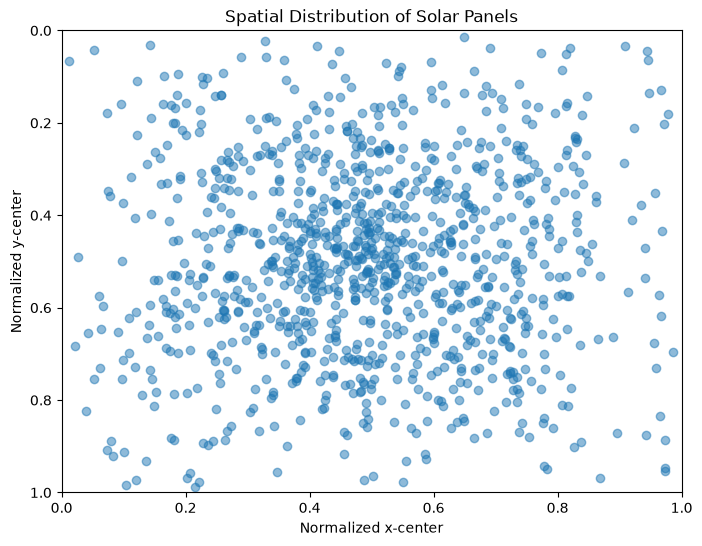

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(box_x_centers, box_y_centers, alpha=0.5)

plt.xlabel('Normalized x-center')
plt.ylabel('Normalized y-center')
plt.title('Spatial Distribution of Solar Panels')

plt.xlim(0, 1)
plt.ylim(1, 0)

plt.show()

## 7. Visualizing the bounding boxes

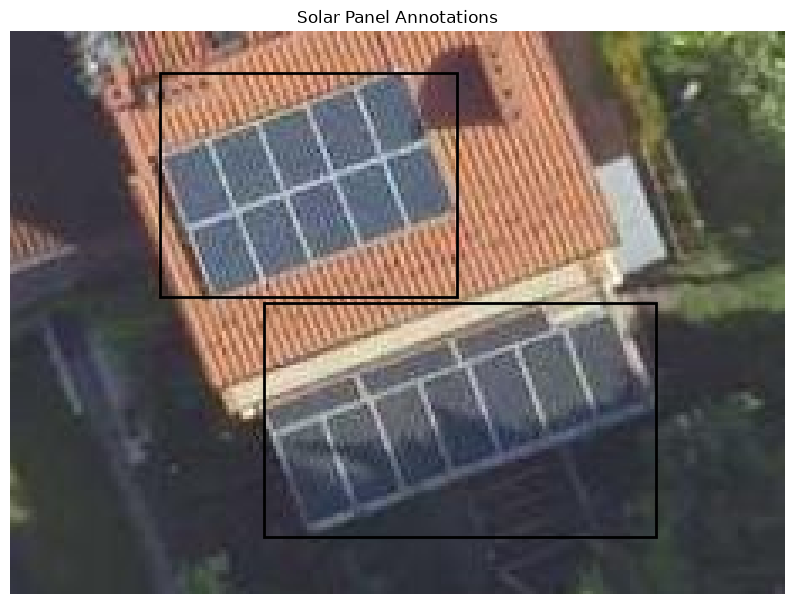

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize(image_file, label_file):
    image_file_path = os.path.join(os.path.join(IMAGES_DIR, 'train'), image_file)
    image_label_path = os.path.join(os.path.join(LABELS_DIR, 'train'), label_file)

    image = Image.open(image_file_path)
    image_width, image_height = image.size

    with open(image_label_path, "r") as f:
        lines = f.readlines()

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image)

    for line in lines:
        values = line.strip().split()

        x_center = float(values[1])
        y_center = float(values[2])
        width = float(values[3])
        height = float(values[4])

        x_center = x_center * image_width
        y_center = y_center * image_height
        width = width * image_width
        height = height * image_height

        x1 = x_center - width / 2
        y1 = y_center - height / 2

        rectangle = patches.Rectangle(
            (x1, y1),
            width,
            height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

    ax.set_title("Solar Panel Annotations")
    ax.axis("off")

    plt.show()


img_file = train_images[45]
lab_file = os.path.splitext(img_file)[0] + ".txt"

visualize(img_file, lab_file)